[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_1/01C-DataHandling.ipynb)

# 01C — Data Handling with pandas
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 1, Notebook C — Hour 3**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook introduces the basic data workflow used throughout the course: getting a table into
Python, checking that it arrived intact, and finding out what is in it.

The goal is not to become a pandas expert. The goal is to develop the habit of looking carefully at
data before fitting models. Its companion, `01D`, takes the same dataset and looks at it in
pictures.

## Learning objectives

By the end of this notebook, students should be able to:

- describe the structure of a tabular dataset, and the vocabulary of samples, features and targets;
- load a dataset into pandas, and check that it loaded correctly;
- inspect rows, columns, data types and missing values;
- select columns, filter rows, derive new columns and sort a table;
- compute summaries, both overall and group by group.

`01D` continues from here, and covers the visual half of the same workflow.

# 1. Why explore data before modeling?

Machine learning does not start with a model. It starts with data.

Suppose we want to predict one scientific measurement from another. Before fitting a model, we should ask:

- Are the measurements reasonable?
- Are there missing values?
- Are there obvious outliers?
- Are the units correct?
- Do the variables appear related?
- Is there anything suspicious in the data?

A machine learning model will usually produce an answer even when the data contain errors. Exploratory analysis helps us detect problems before they contaminate the modelling stage.

> **One thing about the order, promised now and settled in `02C`.** A real project does not
> explore all of its data. It **splits first** — holds part of it back, untouched — and explores
> only the training portion, because anything you learn from the held-back part stops that part
> from being an honest test. This notebook explores everything, and that is deliberate: there is no
> model yet for the held-back data to protect, and the argument for splitting cannot be made before
> you know what a model is. `02C` §2 makes it precise, and step 2 of the pipeline map in `01A` §6
> is where it belongs.

The following toy example illustrates the idea.

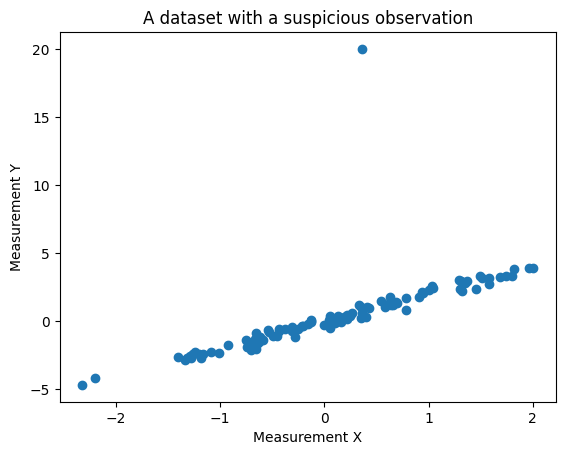

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

x = rng.normal(size=100)
y = 2 * x + rng.normal(scale=0.3, size=100)

y[5] = 20        # one suspicious observation

plt.scatter(x, y)

plt.xlabel("Measurement X")
plt.ylabel("Measurement Y")
plt.title("A dataset with a suspicious observation")

plt.show()

At first sight, the points appear to follow a clear trend:

- larger values of `X` tend to correspond to larger values of `Y`;
- the relationship looks approximately linear;
- however, one observation is far away from all the others.

Before fitting a model, a scientist would usually investigate this point.

Possible explanations include:

- a measurement error;
- a faulty sensor;
- an incorrect unit conversion;
- a data-entry mistake;
- a genuinely unusual observation.

Notice that none of these questions require machine learning. They require understanding the data.

This process is often called **exploratory data analysis (EDA)**.

The goal of EDA is not to build a model. The goal is to understand the dataset well enough that building a model becomes meaningful.

# 2. Dataset anatomy

A tabular dataset is organized as rows and columns.

This structure is simple, but it is the starting point for most machine learning workflows.

The goal of this section is to introduce vocabulary that will appear repeatedly throughout the course:

- observations;
- variables;
- features;
- targets;
- numerical variables;
- categorical variables;
- dataset shape;
- feature space.

## 2.1 What is pandas?

In the previous notebook, we worked mostly with NumPy arrays.

NumPy is excellent for numerical arrays, but real datasets often come with additional structure:

- column names;
- different data types in different columns;
- missing values;
- categorical labels;
- row indices;
- data loaded from CSV or Excel files.

**pandas** is a Python library designed for working with this kind of tabular data.

The central pandas object is the `DataFrame`.

A `DataFrame` is similar to a spreadsheet or a database table:

- it has rows and columns;
- columns have names;
- different columns can contain different kinds of data;
- we can select, filter, group, summarize and plot the data.

pandas is popular because it makes many common data-analysis tasks concise and readable. It is also widely used in scientific computing, data science and machine learning workflows.

However, pandas is not the only option.

Common alternatives include:

- **NumPy**, when the data are purely numerical arrays and performance/simple array operations matter;
- **Polars**, a newer DataFrame library often faster for large tabular datasets;
- **SQL**, when data are stored in relational databases;
- **PySpark** or similar distributed tools, when datasets are too large for a single machine;
- domain-specific tools, when data come from specialized scientific formats.

In this course, we use pandas because it is standard, readable, and sufficient for the small to medium-sized datasets used in teaching.

### What kinds of operations does pandas allow?

At this stage, you do not need to memorize pandas syntax.

The goal is to know what kinds of operations pandas can perform. Specific commands will be introduced when we need them.

Common pandas operations include:

**Inspecting a dataset**

```python
df.head()
df.info()
df.describe()
```

These commands help us understand the structure of a dataset.

**Selecting columns**

```python
df["temperature"]
df[["temperature", "pressure"]]
```

This extracts one column or several columns.

**Selecting rows by condition**

```python
df[df["temperature"] > 300]
```

This keeps only rows satisfying a condition.

**Creating or modifying columns**

```python
df["temperature_K"] = df["temperature_C"] + 273.15
```

This creates a new column from existing information.

**Checking and handling missing values**

```python
df.isna()
df.dropna()
df.fillna(...)
```

These commands help detect and handle incomplete data.

**Grouping and summarizing**

```python
df.groupby("species").mean()
```

This computes summaries separately for each group.

**Plotting**

```python
df.hist()
```

pandas includes some built-in plotting tools; `01D` uses both those and `matplotlib` directly.

The important point is that pandas provides a language for asking questions about tables.

## 2.2 Rows and columns

In a tabular dataset:

- each **row** usually represents one observation, sample, measurement, experiment or object;
- each **column** represents one variable measured on those observations.

For example, suppose we are studying a material under different experimental conditions.

We first import pandas using the conventional abbreviation `pd`.

This abbreviation is not required, but it is almost universally used in Python data-analysis code.

In [2]:
import pandas as pd

materials = pd.DataFrame({
    "sample_id": ["A", "B", "C", "D", "E"],
    "temperature": [295.1, 300.2, 298.7, 301.5, 294.8],
    "pressure": [1.02, 0.98, 1.01, 1.05, 1.00],
    "phase": ["solid", "liquid", "solid", "liquid", "solid"]
})

materials

,sample_id,temperature,pressure,phase
0,A,295.1,1.02,solid
1,B,300.2,0.98,liquid
2,C,298.7,1.01,solid
3,D,301.5,1.05,liquid
4,E,294.8,1.00,solid


In this table:

- each row is one material sample or experimental condition;
- `temperature`, `pressure`, and `phase` are variables;
- `sample_id` is an identifier, not usually a scientific variable to model.

## 2.3 Features and targets

In machine learning, we often distinguish between:

- **features**: the input variables used by the model;
- **target**: the quantity we want to predict.

For example, if we want to predict the material phase from temperature and pressure:

```text
features: temperature, pressure
target:   phase
```

The conventional notation is:

```text
X = features
y = target
```

This notation will appear throughout the course.

Before building any model, we often separate a table into features and target.

Two syntaxes look almost the same and return different things:

| Written | Returns | Dimensions |
|---|---|---|
| `df["col"]` | a **Series** — one column on its own | 1 |
| `df[["col1", "col2"]]` | a **DataFrame** — a table | 2 |

A **Series** is a single labelled column: values and an index, and nothing else. It has no column
headers, because there is only one column and no need to name it more than once. A **DataFrame**
is a collection of Series sharing one index — a table.

This is the pandas version of a distinction met in `01B` §5, between an array of shape `(4,)` and
one of shape `(4, 1)`: the same four numbers, but one of them carries an orientation and the other
does not.

Watch the brackets. `df[["col"]]`, with a **list** inside, returns a DataFrame that happens to have
one column; `df["col"]` returns a Series. From Class 2 onward this matters in a practical way,
because scikit-learn expects the features `X` as a two-dimensional table and the target `y` as a
one-dimensional column.

In [3]:
X = materials[["temperature", "pressure"]]
y = materials["phase"]

X

,temperature,pressure
0,295.1,1.02
1,300.2,0.98
2,298.7,1.01
3,301.5,1.05
4,294.8,1.00


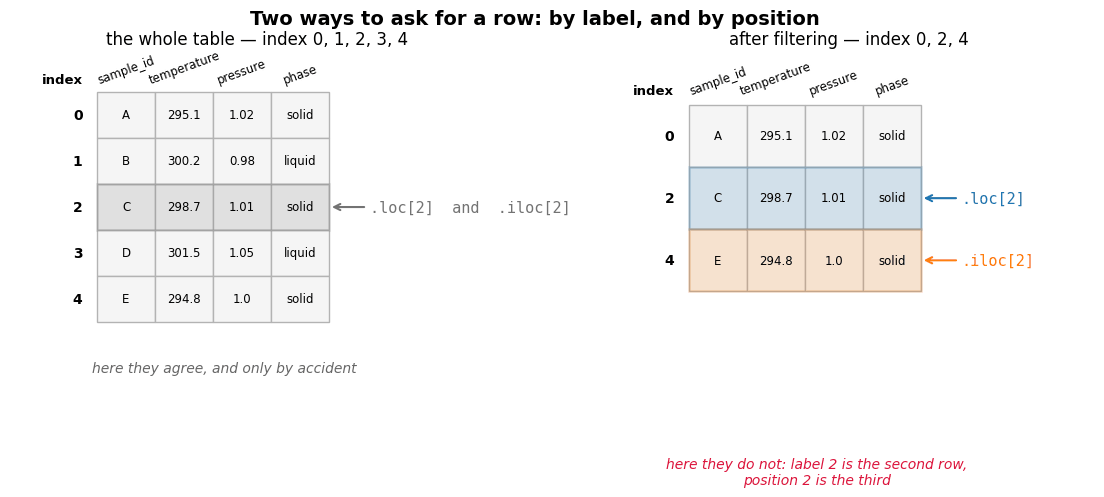

In [4]:
from matplotlib.patches import Rectangle

def draw_table(axis, frame, loc_label, iloc_position, title):
    for row in range(len(frame)):
        for column in range(frame.shape[1]):
            axis.add_patch(Rectangle((column, -row), 1, 1, facecolor="0.96",
                                     edgecolor="0.7", linewidth=1))
            axis.text(column + 0.5, -row + 0.5, str(frame.iloc[row, column]),
                      ha="center", va="center", fontsize=8.5)
        axis.text(-0.25, -row + 0.5, str(frame.index[row]), ha="right", va="center",
                  fontsize=10, fontweight="bold")
    for column, name in enumerate(frame.columns):
        axis.text(column + 0.5, 1.12, name, ha="center", va="bottom", fontsize=8.5, rotation=20)
    axis.text(-0.25, 1.12, "index", ha="right", va="bottom", fontsize=9.5, fontweight="bold")

    by_label = list(frame.index).index(loc_label)
    landings = [(by_label, "tab:blue", f".loc[{loc_label}]"),
                (iloc_position, "tab:orange", f".iloc[{iloc_position}]")]
    if by_label == iloc_position:                     # they coincide: one band, one label
        landings = [(by_label, "0.45", f".loc[{loc_label}]  and  .iloc[{iloc_position}]")]
    for offset, colour, text in landings:
        axis.add_patch(Rectangle((0, -offset), frame.shape[1], 1, facecolor=colour,
                                 alpha=0.16, edgecolor=colour, linewidth=2))
        axis.annotate(text, xy=(frame.shape[1], -offset + 0.5),
                      xytext=(frame.shape[1] + 0.7, -offset + 0.5), fontsize=11,
                      color=colour, va="center", fontfamily="monospace",
                      arrowprops={"arrowstyle": "->", "color": colour, "linewidth": 1.5})
    axis.set_xlim(-1.5, frame.shape[1] + 3.0)
    axis.set_ylim(-len(frame) - 0.9, 1.8)
    axis.axis("off")
    axis.set_title(title, pad=8, fontsize=12)

solids = materials[materials["phase"] == "solid"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
draw_table(axes[0], materials, 2, 2, "the whole table — index 0, 1, 2, 3, 4")
draw_table(axes[1], solids, 2, 2, "after filtering — index 0, 2, 4")
axes[0].text(2.2, -5.1, "here they agree, and only by accident",
             ha="center", fontsize=10, color="0.4", style="italic")
axes[1].text(2.2, -5.1, "here they do not: label 2 is the second row,\nposition 2 is the third",
             ha="center", fontsize=10, color="crimson", style="italic")
fig.suptitle("Two ways to ask for a row: by label, and by position",
             fontsize=14, fontweight="bold")
plt.show()

In [5]:
y

0     solid
1    liquid
2     solid
3    liquid
4     solid
Name: phase, dtype: object

The two displays above look different, and the difference is exactly the one just described. `X` is drawn as a table with column headers; `y` is drawn as a bare column of values with an index down the side and its `dtype` reported underneath. Asking Python directly confirms it.

In [6]:
print("X:", type(X).__name__, "with shape", X.shape)
print("y:", type(y).__name__, "with shape", y.shape)

# The same column, selected with double brackets, is a one-column table instead:
print("materials[['phase']]:", type(materials[["phase"]]).__name__,
      "with shape", materials[["phase"]].shape)

X: DataFrame with shape (5, 2)
y: Series with shape (5,)
materials[['phase']]: DataFrame with shape (5, 1)


Here `X` is a table with the input variables, while `y` contains the target labels.

This does not yet build a model. It only separates the data into the form that a model would later use.

## 2.4 Selecting rows

Section 2.3 selected **columns**. Just as often we want to select **rows** — the samples that
satisfy some condition.

The pattern mirrors the boolean masking we saw with NumPy arrays in `01B`. A comparison on a
column produces a column of `True` and `False`, and putting that inside square brackets keeps the
rows marked `True`.

In [7]:
warm = materials["temperature"] > 298

print(warm)             # one True/False per row
print()
print(materials[warm])  # only the rows where it is True

0    False
1     True
2     True
3     True
4    False
Name: temperature, dtype: bool

  sample_id  temperature  pressure   phase
1         B        300.2      0.98  liquid
2         C        298.7      1.01   solid
3         D        301.5      1.05  liquid


The two steps are usually written as one line. Conditions combine with `&` (and), `|` (or) and
`~` (not), and **each condition needs its own brackets** — exactly as in `01B`.

In [8]:
# Rows whose phase is solid
print(materials[materials["phase"] == "solid"])

print()

# Rows that are warm AND at high pressure
print(materials[(materials["temperature"] > 296) & (materials["pressure"] > 1.0)])

  sample_id  temperature  pressure  phase
0         A        295.1      1.02  solid
2         C        298.7      1.01  solid
4         E        294.8      1.00  solid

  sample_id  temperature  pressure   phase
2         C        298.7      1.01   solid
3         D        301.5      1.05  liquid


### `.loc` and `.iloc`

Two further accessors appear throughout pandas code:

- `df.loc[row_label, column_name]` selects by **label** — the row index and the column's name.
- `df.iloc[row_position, column_position]` selects by **position**, counting from zero, exactly
  like a NumPy array.

In the full table the row labels happen to be `0, 1, 2, …`, so the two coincide. They come apart
as soon as rows are filtered or sorted: the labels travel with the rows, while the positions are
renumbered from zero.

In the example below the filtered table keeps the labels `0, 2, 4`. Asking for *position* 2 and
for *label* 2 therefore returns two different samples. Asking for label `1` would fail outright,
because no surviving row carries that label.

In [9]:
print("materials.loc[2, 'temperature']  ->", materials.loc[2, "temperature"])
print("materials.iloc[2, 1]             ->", materials.iloc[2, 1])

# After filtering, the labels travel with the rows but the positions are renumbered.
solids = materials[materials["phase"] == "solid"]
print()
print(solids)          # note the index: 0, 2, 4 -- not 0, 1, 2
print()
print("solids.iloc[2, 1]             3rd row by position ->", solids.iloc[2, 1])
print("solids.loc[2, 'temperature']  the row labelled 2  ->", solids.loc[2, "temperature"])

materials.loc[2, 'temperature']  -> 298.7
materials.iloc[2, 1]             -> 298.7

  sample_id  temperature  pressure  phase
0         A        295.1      1.02  solid
2         C        298.7      1.01  solid
4         E        294.8      1.00  solid

solids.iloc[2, 1]             3rd row by position -> 294.8
solids.loc[2, 'temperature']  the row labelled 2  -> 298.7


<div class="alert alert-success">
<b>Mini-exercise 1 — Selecting rows</b><br>
Using the <code>materials</code> table:
<br><br>
1. Select the rows whose phase is <code>"liquid"</code>.<br>
2. Select the rows with pressure below 1.01.<br>
3. Select the rows that are liquid <em>and</em> above 300 K.<br>
4. Using <code>.iloc</code>, print the first two rows.
</div>

In [10]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

## 2.5 Numerical and categorical variables

Variables can have different types.

A **numerical variable** represents a quantity:

- temperature;
- pressure;
- mass;
- velocity;
- concentration.

Numerical variables can usually be averaged, subtracted, scaled and plotted on numerical axes.

A **categorical variable** represents a category or label:

- solid / liquid / gas;
- species name;
- material class;
- experimental condition.

Categorical variables usually cannot be averaged in a meaningful way.

The attribute `.dtypes` reports the data type of each column.

This is useful because pandas tables can contain different kinds of data in different columns.

In [11]:
materials.dtypes

sample_id       object
temperature    float64
pressure       float64
phase           object
dtype: object

In this example:

- `temperature` and `pressure` are numerical variables;
- `phase` is categorical;
- `sample_id` is also categorical-like, but it is an identifier rather than a scientific class.

Recognizing variable types is important because different models and plots require different kinds of data.

## 2.5.1 Turning a categorical column into numbers

Recognising a categorical column is the first half. The second half is that **almost every model in
this course refuses to accept one.** `scikit-learn` will raise an error rather than guess what
`"solid"` means numerically — including the decision trees of Class 4, which is a common surprise,
since a tree could in principle branch on a label directly and some other libraries let it.

So a categorical column has to be encoded, and the choice of encoding is a scientific judgement
about what the categories *are*.

**Ordered categories** — `low` < `medium` < `high`, or a crystal system indexed by symmetry — carry
a genuine order, and mapping them to 0, 1, 2 keeps information a model can use.

**Unordered categories** — solid, liquid, gas — do not. Mapping them to 0, 1, 2 invents an order and
tells the model that gas is three times solid and that liquid sits between them. The remedy is
**one-hot encoding**: one new column per category, holding 1 where the row has that category and 0
elsewhere. `pd.get_dummies` does it.

In [12]:
ordered = {"solid": 0, "liquid": 1, "gas": 2}       # an order we are asserting on purpose

encoded = materials.copy()
encoded["phase_ordinal"] = encoded["phase"].map(ordered)

one_hot = pd.get_dummies(materials, columns=["phase"], prefix="is", dtype=int)

print("ordinal — one column, an order asserted:")
print(encoded[["sample_id", "phase", "phase_ordinal"]].to_string(index=False))
print("\none-hot — one column per category, no order asserted:")
print(one_hot[[c for c in one_hot.columns if c.startswith("is_")]].to_string(index=False))
print(f"\ncolumns before: {materials.shape[1]}   after one-hot: {one_hot.shape[1]}")

ordinal — one column, an order asserted:
sample_id  phase  phase_ordinal
        A  solid              0
        B liquid              1
        C  solid              0
        D liquid              1
        E  solid              0

one-hot — one column per category, no order asserted:
 is_liquid  is_solid
         0         1
         1         0
         0         1
         1         0
         0         1

columns before: 4   after one-hot: 5


One-hot costs columns — a variable with fifty categories becomes fifty columns, and with a few such
variables a table becomes mostly zeros. That is the trade, and it is why high-cardinality columns
(a sample identifier, a postcode, a compound name) are usually dropped or grouped rather than
encoded.

> `pd.get_dummies` is the right tool for a one-off exploration, which is what this notebook is about.
> For anything that will be *fitted*, use `scikit-learn`'s `OneHotEncoder` inside a pipeline
> instead. The reason is `02C` §6: an encoder that meets a category for the first time in the test
> set must be told what to do, and only the pipeline version remembers which categories it saw
> during training.

## 2.6 Shape of a dataset

The **shape** of a dataset tells us how many observations and variables it contains.

For a feature matrix `X`, the shape is usually interpreted as:

```text
(number of samples, number of features)
```

This connects directly to the NumPy notation introduced in the previous notebook.

In [13]:
X.shape

(5, 2)

The result means:

```text
5 samples
2 features
```

In later notebooks, we will often see datasets with shapes such as:

```text
(100, 4)      100 samples, 4 features
(1000, 20)    1000 samples, 20 features
(60000, 784)  60000 images, each represented by 784 pixel values
```

The first dimension usually counts observations. The second dimension usually counts features.

## 2.7 Samples as points in feature space

If a dataset has two numerical features, each sample can be viewed as a point in a two-dimensional space.

In our example, each material sample has:

```text
temperature
pressure
```

so each row corresponds to a point:

```text
(temperature, pressure)
```

This geometric viewpoint will become very important later.

It appears in:

- clustering;
- support vector machines;
- dimensionality reduction;
- embeddings;
- neural network representations.

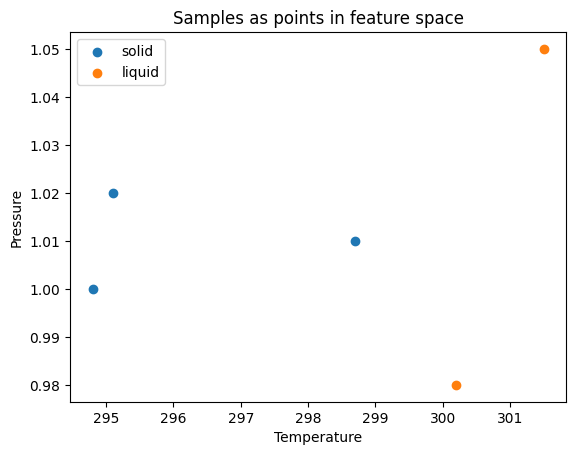

In [14]:
import matplotlib.pyplot as plt

# One scatter call per phase, using the row filtering from section 2.4.
for phase in ["solid", "liquid"]:
    subset = materials[materials["phase"] == phase]
    plt.scatter(subset["temperature"], subset["pressure"], label=phase)

plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.title("Samples as points in feature space")
plt.legend()
plt.show()

The plot is simple, but the idea is powerful.

Each point is one row of the dataset.

The horizontal and vertical coordinates are two features.

The color indicates the target class.

Many machine learning methods can be understood as ways of finding structure in this feature space.

## 2.8 A small scientific prediction problem

The same table can be read as a prediction problem:

> Can we predict the phase of a material from temperature and pressure?

This is a **classification** problem because the target is categorical.

If the target were a continuous number, such as conductivity or energy, the problem would instead be a **regression** problem.

We will study regression and classification in the next lecture. For now, the important point is that the organization of the data already suggests what kind of machine learning problem we may want to solve.

<div class="alert alert-success">
<b>Mini-exercise 2 — Dataset anatomy</b><br>
Using the <code>materials</code> dataset above, identify:
<br><br>
1. the number of observations;<br>
2. the numerical variables;<br>
3. the categorical variables;<br>
4. the feature matrix <code>X</code>;<br>
5. the target <code>y</code>;<br>
6. whether predicting <code>phase</code> is a regression or classification problem.
</div>

In [15]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. Loading data

In real projects, data can come from many sources:

- CSV files exported from instruments or simulations;
- Excel files;
- databases;
- web APIs;
- manually curated tables;
- output files produced by other programs.

In this course, we will mostly use **tabular data**. The most common tabular file format is CSV.

CSV means **comma-separated values**. A CSV file is just a text file where each row is one line and values are separated by commas.

For example:

```text
temperature,pressure,phase
295.1,1.02,solid
300.2,0.98,liquid
298.7,1.01,solid
```

Pandas loads CSV files using:

```python
pd.read_csv(...)
```

## 3.1 Loading a CSV file

The argument of `pd.read_csv` can be:

- a local file path, such as `"data/iris.csv"`;
- a URL pointing to a CSV file.

For classroom notebooks, URLs are convenient, but local files are more reliable.

Here we use the Iris dataset. It is small, classical, and useful for introducing both visualization and classification.

`pd.read_csv(...)` loads a CSV file and returns a pandas `DataFrame`.

The input can be a local file path or a URL.

In [16]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

iris = pd.read_csv(url)

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The result is a pandas `DataFrame`.

A `DataFrame` is a table with:

- row indices;
- column names;
- values;
- data types.

In this dataset, each row is one flower, and the columns contain measurements and a species label.

## 3.2 Loading data robustly

The previous cell is simple, but it depends on internet access.

For teaching, it is often safer to include a fallback.

The next version first tries to load the Iris dataset from the URL. If that fails, it loads the Iris dataset from `scikit-learn`, which is commonly installed in machine learning environments.

This pattern is useful in teaching notebooks because it avoids breaking the whole lecture because of a network problem.

The `try` / `except` form is Python's way of saying *attempt this; if it goes wrong, do that
instead*. **You are not expected to write it yet** — this cell is infrastructure, not material, and
you can use the dataset without following how it was loaded.

In [17]:
try:
    iris = pd.read_csv(url)
    data_source = "online CSV"
except Exception:
    from sklearn.datasets import load_iris

    bunch = load_iris(as_frame=True)
    iris = bunch.frame.rename(columns={
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width"
    })
    iris["species"] = iris["target"].map(dict(enumerate(bunch.target_names)))
    iris = iris.drop(columns="target")
    data_source = "scikit-learn fallback"

data_source

'online CSV'

## 3.3 Checking that the data loaded correctly

Loading a dataset is not enough.

Immediately after loading, we should check:

- whether the object exists;
- whether the first rows look reasonable;
- whether the column names are what we expect;
- whether the number of rows and columns makes sense.

A useful habit is:

```python
df.head()
df.shape
df.columns
```

The attribute `.columns` returns the column names. They matter because pandas operations refer to columns by name rather than by numerical position.

In [18]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

## 3.4 File paths

If the file is stored locally, the command may look like this:

```python
pd.read_csv("data/iris.csv")
```

This means:

- the notebook is in one folder;
- inside that folder there is a subfolder called `data`;
- inside `data` there is a file called `iris.csv`.

A common source of errors is that the file is not where the notebook expects it to be.

If loading fails, check:

- the file name;
- the folder name;
- spelling and capitalization;
- whether the notebook is being run from the expected directory.

<div class="alert alert-success">
<b>Mini-exercise 3 — Loading and checking data</b><br>
Using the Iris dataset loaded above:
<br><br>
1. Display the first 10 rows.<br>
2. Display the number of rows and columns.<br>
3. Display the column names.<br>
4. Identify which column could be used as a classification target.
</div>

In [19]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 4. The first five minutes with a new dataset

When receiving a new dataset, experienced practitioners tend to follow a fairly consistent workflow.

The goal is not to start modelling immediately.

The goal is to answer a few basic questions:

- What does the dataset contain?
- How large is it?
- What kinds of variables does it contain?
- Are there obvious problems?
- Does anything look surprising?

A useful first habit is to run:

```python
df.head()
df.shape
df.info()
df.describe()
```

These four commands often reveal most of the information needed to begin exploring a dataset.

## 4.1 What does the dataset look like?

The first thing we usually do is inspect the first few rows.

In [20]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Looking at the first rows helps answer several questions:

- What do the columns represent?
- Are the column names meaningful?
- Do the values look reasonable?
- Are there obvious formatting problems?

For example, the Iris dataset contains:

```text
sepal_length
sepal_width
petal_length
petal_width
species
```

Even before plotting anything, we can already recognize that:

- four columns contain measurements;
- one column contains a species label;
- the dataset is likely suitable for a classification problem.

## 4.2 How large is the dataset?

The shape tells us how many observations and variables are present.

In [21]:
iris.shape

(150, 5)

The output

```text
(150, 5)
```

means:

```text
150 observations
5 variables
```

The first number is usually the number of rows.

The second number is usually the number of columns.

In [22]:
len(iris)

150

`len(df)` is a useful shortcut that returns the number of rows in a DataFrame.

For the Iris dataset:

```text
150 flowers
```

were measured.

## 4.3 Sorting: looking at the extremes

Averages hide the interesting rows. To see the largest or smallest values, sort the table with
`.sort_values(column)`.

Sorting returns a **new** table; it does not reorder the original. Add `ascending=False` for
largest-first.

In [23]:
# The five flowers with the largest petals
iris.sort_values("petal_length", ascending=False).head()

,sepal_length,sepal_width,petal_length,petal_width,species
118,7.7,2.6,6.9,2.3,virginica
122,7.7,2.8,6.7,2.0,virginica
117,7.7,3.8,6.7,2.2,virginica
105,7.6,3.0,6.6,2.1,virginica
131,7.9,3.8,6.4,2.0,virginica


In [24]:
# The five smallest
iris.sort_values("petal_length").head()

,sepal_length,sepal_width,petal_length,petal_width,species
22,4.6,3.6,1.0,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa
36,5.5,3.5,1.3,0.2,setosa


This is often the fastest way to spot a data-quality problem: an impossible value, a negative
measurement, or a placeholder such as `-999` used to mean "missing", will usually appear at one
end of a sort.

## 4.4 What types of variables do we have?

The next step is to inspect the data types.

In [25]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Several details are worth noticing.

Numerical measurements appear as:

```text
float64
```

This means the values are stored as double-precision floating-point numbers.

The species column appears as:

```text
object
```

In pandas, `object` often indicates text data.

This distinction is important because:

- numerical variables can be averaged, scaled and correlated;
- categorical variables usually represent labels or classes and require different treatment.

## 4.5 What ranges of values do we have?

The next command computes basic descriptive statistics.

> One number in that table is worth a footnote. The `std` row is the **sample** standard deviation,
> dividing by $n-1$, which is what pandas uses everywhere. NumPy's `.std()` — the one used in `01B`
> — divides by $n$ instead. On 150 rows the difference is negligible, but it is why `ddof=1` appears
> explicitly in some later cells: it asks NumPy for the pandas convention, so that the two agree.

In [26]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The output contains:

```text
count
mean
std
min
25%
50%
75%
max
```

where:

- `count` is the number of non-missing observations;
- `mean` is the average value;
- `std` is the standard deviation;
- `min` and `max` are the smallest and largest values;
- `50%` is the median;
- `25%` and `75%` are quartiles.

A useful mental picture is:

```text
min ---- 25% ---- median ---- 75% ---- max
```

Quartiles help describe how the data are distributed without looking at every observation individually.

## 4.6 A scientist's checklist

After running the first four commands, it is useful to pause and ask:

1. What does each row represent?
2. What does each column represent?
3. Which variables are numerical?
4. Which variables are categorical?
5. Are there missing values?
6. Do the numerical ranges look reasonable?
7. Are there obvious data-quality issues?
8. Which column could be a prediction target?

Developing this habit is often more valuable than memorizing additional pandas commands.

## 4.7 Mini case study

Using only:

```python
iris.head()
iris.info()
iris.describe()
```

what can we already infer?

Possible observations:

- the dataset contains 150 flowers;
- there are four numerical measurements;
- there is one categorical label;
- there are no obvious missing values;
- the measurements have similar numerical scales;
- the dataset appears suitable for a classification problem.

Notice that we have not yet plotted the data and we have not trained any model.

Nevertheless, we already understand much more about the dataset than we did immediately after loading it.

<div class="alert alert-success">
<b>Mini-exercise 4 — The first five minutes</b><br>
Using only:
<br><br>
<code>head()</code>, <code>shape</code>, <code>info()</code> and <code>describe()</code>
<br><br>
write down:
<br><br>
1. the number of observations;<br>
2. the number of variables;<br>
3. the numerical variables;<br>
4. the categorical variables;<br>
5. one possible machine learning task that could be performed using this dataset.
</div>

In [27]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Missing values

Real datasets often contain missing values.

A missing value means that an entry is absent, unknown, unavailable or not recorded.

Examples:

- a sensor failed during an experiment;
- a measurement was below the detection threshold;
- an instrument was not calibrated;
- a participant skipped a question;
- a simulation crashed for some parameter values;
- a file was merged incorrectly.

Missing values matter because many machine learning algorithms cannot use them directly.

Before modeling, we need to know whether they are present and why they are present.

## 5.1 Checking missing values

In pandas, missing values are often represented as `NaN`, meaning "Not a Number".

The standard first check is:

```python
df.isna().sum()
```

This counts how many missing values appear in each column.

The expression

```python
df.isna()
```

checks whether each entry is missing.

Combining it with

```python
.sum()
```

counts how many missing values appear in each column.

In [28]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

The Iris dataset is clean: all counts are zero.

Most real datasets are not this clean.

To illustrate the issue, we will create a small copy of the Iris dataset and manually insert some missing values.

The `.loc[row, column]` syntax selects entries by row label and column name.

Here we use it only to create a teaching example with artificial missing values.

In [29]:
iris_missing = iris.copy()

iris_missing.loc[3, "sepal_length"] = np.nan
iris_missing.loc[8, "petal_width"] = np.nan
iris_missing.loc[20, "species"] = np.nan

iris_missing.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,NaN,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,NaN,setosa
9,4.9,3.1,1.5,0.1,setosa


In [30]:
iris_missing.isna().sum()

sepal_length    1
sepal_width     0
petal_length    0
petal_width     1
species         1
dtype: int64

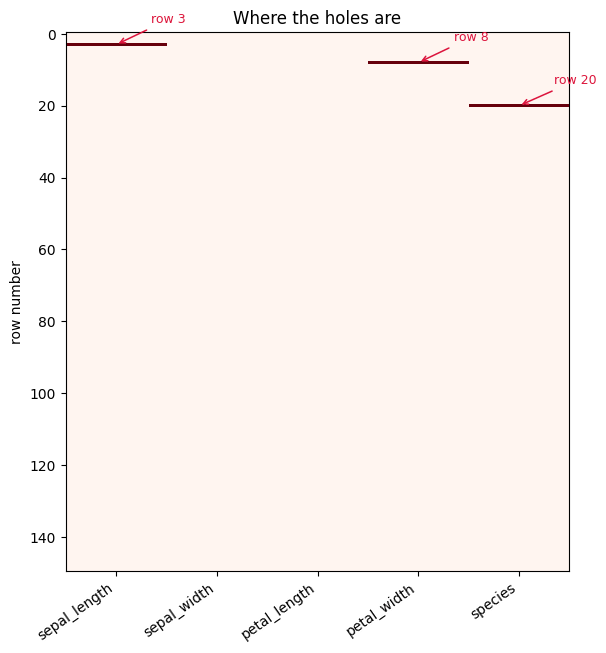

what .isna().sum() counts is the number of red cells in each column


In [31]:
holes = iris_missing.isna()

plt.figure(figsize=(6.5, 7))
plt.imshow(holes.to_numpy(), aspect="auto", cmap="Reds", vmin=0, vmax=1,
           interpolation="nearest")
plt.xticks(range(holes.shape[1]), holes.columns, rotation=35, ha="right")
plt.ylabel("row number")
plt.title("Where the holes are")
for row, column in zip(*np.where(holes.to_numpy())):
    plt.annotate(f"row {row}", xy=(column, row), xytext=(column + 0.35, row - 6),
                 fontsize=9, color="crimson",
                 arrowprops={"arrowstyle": "->", "color": "crimson", "linewidth": 1.1})
plt.grid(False)
plt.show()

print("what .isna().sum() counts is the number of red cells in each column")

Now we see that three columns contain missing values.

This does not yet tell us what to do.

It only tells us where missing values are located.

## 5.2 Inspecting rows with missing values

After counting missing values, we often want to inspect the affected rows.

This helps us understand whether the missing values look isolated or systematic.

Boolean filtering is a common pandas pattern.

The inside expression creates a sequence of `True` and `False` values.

The outer expression uses that sequence to keep only the rows marked `True`.

Here, the condition means: keep rows that contain at least one missing value.

In [32]:
iris_missing[iris_missing.isna().any(axis=1)]

,sepal_length,sepal_width,petal_length,petal_width,species
3,NaN,3.1,1.5,0.2,setosa
8,4.4,2.9,1.4,NaN,setosa
20,5.4,3.4,1.7,0.2,NaN


The expression

```python
iris_missing.isna().any(axis=1)
```

creates a Boolean value for each row:

- `True` if the row contains at least one missing value;
- `False` otherwise.

We then use this Boolean mask to select the rows with missing values.

## 5.3 Why missing values are not just a technical problem

A common beginner mistake is to treat missing values as an inconvenience to remove quickly.

But missingness can contain scientific information.

For example:

- a missing chemical measurement may indicate that a reaction failed;
- a missing medical value may indicate that a test was not ordered;
- a missing astronomical measurement may indicate that an object was too faint;
- a missing sensor reading may indicate an extreme operating condition.

In these cases, deleting missing values may remove important information.

The first question should be:

> Why is this value missing?

not:

> How do I get rid of it?

## 5.4 Common strategies

There is no universal solution for missing values.

Common strategies include:

1. **Do nothing for now**  
   Keep the missing values during exploratory analysis.

2. **Drop rows**  
   Remove observations with missing values.

3. **Drop columns**  
   Remove variables with too many missing values.

4. **Impute values**  
   Replace missing values with estimates, such as a mean, median or model-based prediction.

5. **Add a missingness indicator**  
   Create a new variable recording whether a value was missing.

Which strategy is appropriate depends on the data, the scientific question and the model.

## 5.5 Dropping missing values

The simplest strategy is to remove rows containing missing values.

This is easy, but it can discard useful data.

The method `.dropna()` removes rows containing missing values.

This is simple, but it may discard useful data.

In [33]:
iris_missing.dropna().shape

(147, 5)

In [34]:
iris_missing.shape

(150, 5)

In this small example, dropping missing rows removes only a few observations.

In a real dataset, it may remove a large fraction of the data.

Always check how much data is lost.

## 5.6 Simple imputation

Another simple strategy is to replace missing numerical values with the column mean or median.

This is called **imputation**.

For example, we can fill the missing `sepal_length` value with the mean sepal length.

In [35]:
sepal_mean = iris_missing["sepal_length"].mean()

sepal_mean

np.float64(5.851677852348993)

The method `.fillna(value)` replaces missing values with the value we provide.

Here we fill only one numerical column using its mean.

In [36]:
iris_filled = iris_missing.copy()

iris_filled["sepal_length"] = iris_filled["sepal_length"].fillna(sepal_mean)

iris_filled.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     1
species         1
dtype: int64

Only the missing value in `sepal_length` was filled.

The other missing values remain because they are in different columns.

For categorical variables, filling with a numerical mean does not make sense.

This is why missing-value handling is not just a syntax issue. It requires understanding variable types.

## 5.7 A rule for handling missing values

For this course, use the following rule:

> In exploratory analysis, detect and understand missing values.  
> In modeling, decide explicitly how to handle them.

Do not silently drop or fill missing values without recording what you did.

And one rule that belongs to modelling rather than to exploring, stated here so it is not a
surprise later: **a filled-in value must be computed from the training data alone.** The median
used above was taken over the whole table, which is fine for looking at it. Fill a test row with a
median that was computed using that same test row, and the test is no longer a test. `02C` §6.3
shows the machinery — a `SimpleImputer` inside a pipeline — that makes this automatic.

<div class="alert alert-success">
<b>Mini-exercise 5 — Missing values</b><br>
Using <code>iris_missing</code>:
<br><br>
1. Count missing values in each column.<br>
2. Display the rows that contain at least one missing value.<br>
3. Drop the rows with missing values and check the new shape.<br>
4. Fill the missing value in <code>petal_width</code> with the median petal width.<br>
5. Explain why filling the missing <code>species</code> value with a mean would not make sense.
</div>

In [37]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 6. Basic summaries

After loading and inspecting a dataset, the next step is to summarize it.

Summaries help answer questions such as:

- How many observations belong to each category?
- What is the average value of each numerical variable?
- How much do values vary?
- Are groups different from each other?
- Do the numbers look reasonable?

This is still exploratory analysis. We are not yet fitting a model.

We are trying to understand what kind of dataset we have.

## 6.1 Summarizing categorical variables

For categorical variables, a common first question is:

> How many observations are there in each category?

For the Iris dataset, the categorical variable is `species`.

The method `.value_counts()` counts how often each value appears in a column.

This is especially useful for categorical variables.

In [38]:
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

The dataset contains the same number of samples for each species.

This is useful to know. Many real datasets are not balanced.

For example, a medical dataset may contain many healthy patients and only a few patients with a rare disease. A classification model trained on such data can behave very differently from a model trained on balanced data.

## 6.2 Summarizing numerical variables

For numerical variables, useful summaries include:

- mean;
- standard deviation;
- minimum;
- maximum;
- quartiles.

We already saw all of these in section 4.5, using `.describe()`.

The mean gives a typical value, while the standard deviation gives a rough measure of spread.

However, global summaries can hide important structure.

For example, if several species have different petal lengths, the global mean mixes them together.

This is why group-wise summaries are often more informative.

## 6.3 Group-wise summaries

Sometimes we want to compute summaries separately for different groups.

For example:

> What is the average petal length for each species?

This is where `groupby` becomes useful.

The `groupby` operation splits a dataset into groups, applies a calculation to each group, and combines the results.

Here we group rows by species and compute the mean of each numerical column inside each group.

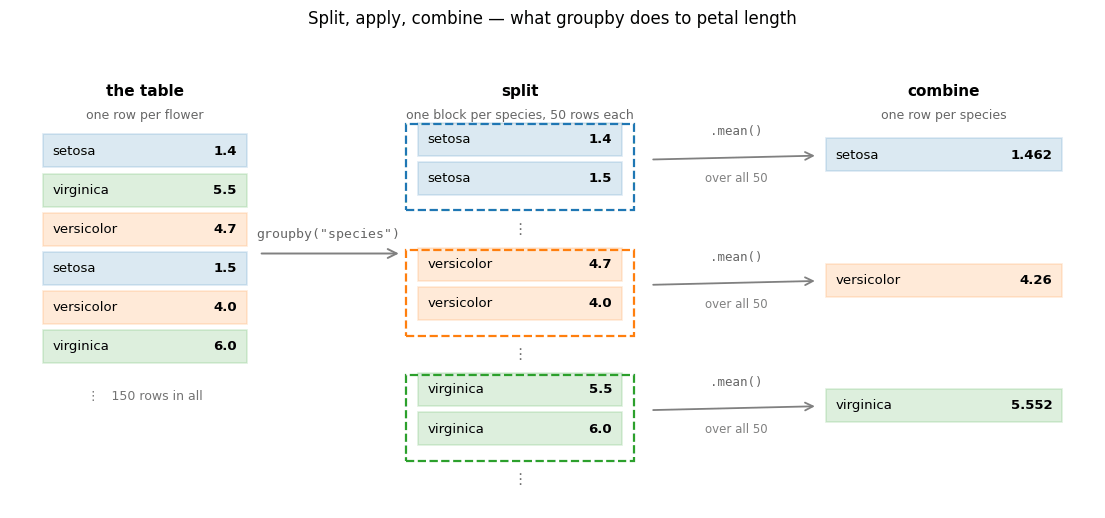

In [39]:
# Figure code — an illustration, not material.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

species=["setosa","versicolor","virginica"]
colours=["tab:blue","tab:orange","tab:green"]
means=[1.462,4.260,5.552]
rows=[("setosa",1.4),("virginica",5.5),("versicolor",4.7),("setosa",1.5),
      ("versicolor",4.0),("virginica",6.0)]
fig, axis = plt.subplots(figsize=(14,6.0))
def row_box(x,y,label,value,colour,w=2.5,h=0.42):
    axis.add_patch(Rectangle((x,y),w,h,facecolor=colour,alpha=0.16,edgecolor=colour,linewidth=1.2))
    axis.text(x+0.12,y+h/2,label,ha="left",va="center",fontsize=9.5)
    axis.text(x+w-0.12,y+h/2,f"{value}",ha="right",va="center",fontsize=9.5,fontweight="bold")

for k,(sp,val) in enumerate(rows):
    row_box(0, 3.4-0.5*k, sp, val, colours[species.index(sp)])
axis.text(1.25, 3.4+0.92, "the table", ha="center", fontsize=11, fontweight="bold")
axis.text(1.25, 3.4+0.62, "one row per flower", ha="center", fontsize=9, color="0.4")
axis.text(1.25, 3.4-0.5*len(rows)+0.16, "\u22ee   150 rows in all", ha="center", va="top",
          fontsize=9, color="0.45")

tops=[3.55,1.95,0.35]
for g,(sp,colour,top) in enumerate(zip(species,colours,tops)):
    members=[v for s,v in rows if s==sp]
    for k,val in enumerate(members):
        row_box(4.6, top-0.5*k, sp, val, colour)
    axis.add_patch(Rectangle((4.45, top-0.5*len(members)+0.42-0.12), 2.8, 0.5*len(members)+0.1,
                             facecolor="none", edgecolor=colour, linewidth=1.6, linestyle="--"))
axis.text(5.85, 3.4+0.92, "split", ha="center", fontsize=11, fontweight="bold")
axis.text(5.85, 3.4+0.62, "one block per species, 50 rows each", ha="center", fontsize=9, color="0.4")

for g,(sp,colour,top,m) in enumerate(zip(species,colours,tops,means)):
    row_box(9.6, top-0.2, sp, m, colour, w=2.9)
    axis.add_patch(FancyArrowPatch((7.45, top-0.05), (9.5, top), arrowstyle="->",
                                   mutation_scale=14, color="0.5", linewidth=1.3))
    axis.text(8.5, top+0.26, ".mean()", ha="center", fontsize=9, color="0.4",
              fontfamily="monospace")
    axis.text(8.5, top-0.34, "over all 50", ha="center", fontsize=8.5, color="0.5")
    axis.text(5.85, top - 0.5 * len(members) + 0.16, "\u22ee", ha="center", va="top",
              fontsize=11, color="0.45")
axis.text(11.05, 3.4+0.92, "combine", ha="center", fontsize=11, fontweight="bold")
axis.text(11.05, 3.4+0.62, "one row per species", ha="center", fontsize=9, color="0.4")
axis.add_patch(FancyArrowPatch((2.65, 2.3), (4.4, 2.3), arrowstyle="->", mutation_scale=16,
                               color="0.5", linewidth=1.4))
axis.text(3.5, 2.5, 'groupby("species")', ha="center", fontsize=9.5, color="0.4",
          fontfamily="monospace")
axis.set_xlim(-0.4, 12.9); axis.set_ylim(-0.95, 4.95); axis.axis("off")
axis.set_title("Split, apply, combine — what groupby does to petal length", pad=16)
plt.show()

In [40]:
iris.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


This table is already scientifically informative.

For example:

- `setosa` has much smaller petal length and petal width than the other species;
- `virginica` tends to have the largest petals;
- sepal measurements differ too, but the separation is less dramatic.

This suggests that petal measurements may be useful for distinguishing species.

## 6.4 Variation within groups

Means are useful, but they do not tell us how much individual samples vary within each group.

The standard deviation gives a simple measure of variation.

In [41]:
iris.groupby("species").std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


A small standard deviation means that values in the group are relatively concentrated around the mean.

A large standard deviation means that values vary more widely.

When comparing groups, both the difference between means and the spread within each group matter.

Two groups may have different means but still overlap strongly if their variability is large.

## 6.5 Selecting only relevant numerical columns

Sometimes a DataFrame contains both numerical and categorical columns.

Some operations, such as computing means or correlations, should only be applied to numerical columns.

We can define a list of numerical columns and use it to select the part of the dataset we want.

In [42]:
numeric_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris[numeric_columns].head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


The expression

```python
iris[numeric_columns]
```

selects only the columns whose names are listed in `numeric_columns`.

This pattern will be useful later when we build feature matrices for machine learning.

## 6.6 Feature engineering: deriving a new column

Assigning to a column name that does not yet exist **creates** it. The calculation is applied to
the whole column at once, exactly like a vectorized NumPy operation.

This is the simplest form of **feature engineering**: building a new variable that expresses
something the raw measurements only imply.

In [43]:
iris_derived = iris.copy()

iris_derived["petal_ratio"] = iris_derived["petal_length"] / iris_derived["petal_width"]
iris_derived["sepal_area"] = iris_derived["sepal_length"] * iris_derived["sepal_width"]

iris_derived.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_area
0,5.1,3.5,1.4,0.2,setosa,7.0,17.85
1,4.9,3.0,1.4,0.2,setosa,7.0,14.70
2,4.7,3.2,1.3,0.2,setosa,6.5,15.04
3,4.6,3.1,1.5,0.2,setosa,7.5,14.26
4,5.0,3.6,1.4,0.2,setosa,7.0,18.00


A derived feature is worth building when it captures something meaningful. Here the petal ratio is
a shape descriptor: it stays roughly constant if a flower is simply larger overall, so it isolates
*proportion* from *size*.

Whether it helps is an empirical question — and we can ask it immediately, with a group-wise
summary.

In [44]:
iris_derived.groupby("species")["petal_ratio"].mean()

species
setosa        6.908000
versicolor    3.242837
virginica     2.780662
Name: petal_ratio, dtype: float64

Always work on a copy, as above, unless you intend to modify the original table. A derived column
added by mistake to a shared dataset is a genuinely annoying bug to track down.

## 6.7 From summaries to hypotheses

Basic summaries do not prove anything, but they help us form hypotheses.

From the Iris summaries, we might hypothesize that:

- petal length and petal width are important for distinguishing species;
- setosa may be easier to separate than the other two species;
- sepal measurements may contain useful but weaker information.

The next step is to visualize these patterns.

Tables are useful, but plots often make structure much easier to see.

<div class="alert alert-success">
<b>Mini-exercise 6 — Basic summaries</b><br>
Using the Iris dataset:
<br><br>
1. Count the number of samples per species.<br>
2. Compute the mean of each numerical variable grouped by species.<br>
3. Compute the standard deviation of each numerical variable grouped by species.<br>
4. Based on these summaries, which measurements seem most useful for distinguishing the species?
</div>

In [45]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Data exploration comes before modelling, not after it.
- Rows usually represent observations; columns represent variables.
- pandas is the standard tool for inspecting and manipulating tabular data.
- Always check shape, types, ranges and missing values before anything else.
- A missing value is a fact about the experiment, not only a gap in a table: why it is missing
  decides what may be done about it.
- Grouped summaries answer questions that overall summaries hide.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- loading a CSV file, with a fallback if the network is unavailable;
- checking a DataFrame with `head`, `shape`, `info` and `describe`;
- selecting rows and columns, and telling `.loc` from `.iloc`;
- recognising a categorical column, and encoding one;
- counting missing values, and saying what dropping or filling each one assumes;
- computing group-wise summaries.

Notebook `01D` takes the same dataset and asks what it *looks* like. Summaries and pictures answer
different questions, and it ends by showing four datasets whose summary statistics agree exactly
and whose pictures look nothing alike.